# Finding a Gel's Poisson's Ratio 

The Poisson's Ratio describes the relationship between a material’s shape and volume under strain. In this context, it would be how the gel's width (or transverse strain) changes in function to its length (or lateral strain) as it is stretched or compressed.

Its value between conditions is one way to describe its behavior under tension and compression and characterize its nature.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from analysis_tools.image_analysis import load_images_poisson_ratio, process_image
import analysis_tools.poisson_ratio as pr

plt.rcParams.update({
    "font.family" : "serif",
    "font.serif" : ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size" : 15,
    "figure.dpi" : 300,
    "savefig.bbox" : "tight"
})

In [2]:
# change and select as needed
root = ".."
dates = ["26-04-13", "26-04-15"]

## Image Analysis : Border Segmentation

In this experimental setup, the gel is not a rectangle so is width is not constant along its length. Also, during the image analysis process, because shadows, field of view limits, and varying gel behavior, the gel borders may not be fully segmented. Having multiple width calculation methods increases the probability of a value to be calculated as well as give a choice for a method that is most representative of the change.

In [ ]:
methods = {
    "min" : pr.get_min_width, 
    "min max" : pr.get_min_max_y_diff, 
    "median" : pr.get_median_x, 
    "median2" : pr.get_median_of_median_x, 
    "mean" : pr.get_mean_width
}

In [ ]:
methods_to_use = ["min", "min max", "median", "median2" "mean"]

In [ ]:
for d in dates :
    date_path = Path(root) / "data" / d # change as needed
    
    # get all conditions for 1 day
    conditions = [x for x in os.listdir(date_path) if len(x.split(".")) == 1] 
        # the if len(x.split(".") == 1) is to ensure that we are storing folder names, not file names, as file names have a .extension

    for c in conditions :
        condition_path = Path(date_path) / c
        
        # get all gels for 1 condition
        gels = [x for x in os.listdir(condition_path) if len(x.split(".")) == 1]

        for g in gels :
            print(f"working on {d} {c} {g}")

            # get high strain data for 1 gel
            gel_path = Path(condition_path) / g / "RampToFracture_1" / "Default"

            # skip if the gel does not have such an experiment
            if not gel_path.exists() :
                print("\t\t(!) This gel does not have a high strain experiment.\n")
                print(f"\t{gel_path}")
                continue 

            # load all frames
            img_lst = load_images_poisson_ratio(gel_path)
            print("\tloaded images")

            measurements = []; lateral_deformations = []; curve_coordinates = []

            for i in range(len(img_lst)) :
                img = img_lst[i]

                print(f"\rprocessing image index: {i+1}/{len(img_lst)}", end="", flush=True)

                # get rod border coordinates
                cropped_img, (oL, iL, iR), (left_border, right_border) = process_image(img, check=False)

                # add distance between inner right and inner left borders
                lateral_deformations.append(iR - iL)

                # get skeleton coordinates
                skeleton_coordinates = pr.get_gel_borders(cropped_img, check=False)

                # get x-y coordinates for upper and lower curves
                upper_x, upper_y, lower_x, lower_y = pr.get_curves(skeleton_coordinates)
                
                # add x-y coordinates of upper and lower curves
                curve_coordinates.append((upper_x,upper_y, lower_x, lower_y))

            print("\n\tobtained lateral lengths and curve coordinates")

            data = dict()
            data["lat_length"] = lateral_deformations

            # attempt transverse length extraction
            transverse_method_measurements = dict()
            used_methods = []
            for m in methods_to_use :
                try :
                    all_extrema = []
                    transverse_deformations = {
                        "by y" : [],
                        "by point" : []
                    }

                    for ux, uy, lx, ly in curve_coordinates :

                        # calculate extrema and distances between extrema using given method
                        extrema, y_diff, point_dist = methods[m](ux, uy, lx, ly)

                        all_extrema.append(extrema)
                        transverse_deformations["by y"].append(y_diff)
                        transverse_deformations["by point"].append(point_dist)

                    data[f"trans_length {m}"] = transverse_deformations["by point"] # change to "by y" as needed
                    
                    print(f"\tobtained transverse lengths using {m}")
                    used_methods.append(m)

                except Exception as error :
                    print(f"\n\t(!) failed to use {m} -> {error}\n")

            # calculate lateral strain
            data["lat_strain"] = pr.calculate_strain(data["lat_length"])
            print("\tcalculated lateral strain\n")

            # calculate transverse strains from available methods
            for m in used_methods :
                data[f"trans_strain {m}"] = pr.calculate_strain(data[f"trans_length {m}"])
                print(f"\tcalculated transverse strain with {m}")
            print()

            # calculate poisson's ratio from available strain
            for m in used_methods :
                try :
                    data[f"poisson {m}"] = [pr.calculate_poisson_ratio(data["lat_length"], data[f"trans_length {m}"])]
                    
                    print(f"\tcalculated poisson ratio with {m}")

                except Exception as error :
                    print(f"\n\t(!) failed to calculate poisson ratio -> {error}\n")
                    data[f"poisson {m}"] = [np.nan]
            print()

            df = pd.DataFrame.from_dict(data, orient="index").T
            
            # save Excel in date directory
            file_name = Path(root) / "data" / d / f"{d}_poisson_ratio.xlsx"

            if not os.path.exists(file_name) :
                with pd.ExcelWriter(file_name, engine="openpyxl", mode="w") as writer :
                    df.to_excel(writer, sheet_name=f"{c}_{g}", index=False)
            else :
                # a new sheet to existing file
                with pd.ExcelWriter(file_name, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer :
                    df.to_excel(writer, sheet_name=f"{c}_{g}", index=False, startrow=0)

            print("loaded data into excel sheet")
            print("\n---\n")

## Strain and Poisson's Ratio Calculations & Visualization

Each gel's data is stored in a sheet. 

| lat_length | trans_length `method1` | ... | trans_length `method5` | lat_strain | trans_strain `method1` | ... | trans_strain `method5` | poisson `method1` | ... | poisson `method5` |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |

If you want to compare all data points across multiple dates, you would need to know all the conditions that exist and the methods that were most successful.

In [3]:
conditions = []
available_methods = dict()

In [4]:
for d in dates :
    excel_path = Path(root) / "data" / f"{d}_poisson_ratio.xlsx" 
    xl_file = pd.ExcelFile(excel_path)

    for gel in xl_file.sheet_names :
        c = gel.split("_")[0]
        if c not in conditions : conditions.append(c)

        gel_df = pd.read_excel(xl_file, sheet_name=gel)
        used_methods = [c[8:] for c in gel_df.columns if c[:7] == "poisson"]
        for m in used_methods :
            if m not in available_methods : available_methods[m] = 1
            else : available_methods[m] += 1

sorted_available_methods = {k:v for k,v in sorted(available_methods.items(), key=lambda item: item[1])}
print(sorted_available_methods)

conditions = sorted(conditions)

{'method1': 56}


Based on the most successful methods, choose which ones to consider.

In [ ]:
selected_methods = ["method1"] # change as needed

In [6]:
# get color maps (using 2 maximizes the number of colors available in the case of many conditions)
plasma_cmap = mpl.colormaps["plasma"]; viridis_cmap = mpl.colormaps["viridis"]

# divide each color map so that there are exactly the same number of colors as there are conditions
s1 = len(conditions)//2; s2 = len(conditions) - s1

plasma_colors = list(plasma_cmap(np.linspace(start=0, stop=0.9, num=s1)))
viridis_colors = list(reversed(list(viridis_cmap(np.linspace(start=0.3, stop=0.9, num=s2)))))
pv_colors = plasma_colors + viridis_colors # add colormaps together

# assign colors
colors = {conditions[i]:pv_colors[i] for i in range(len(conditions))}

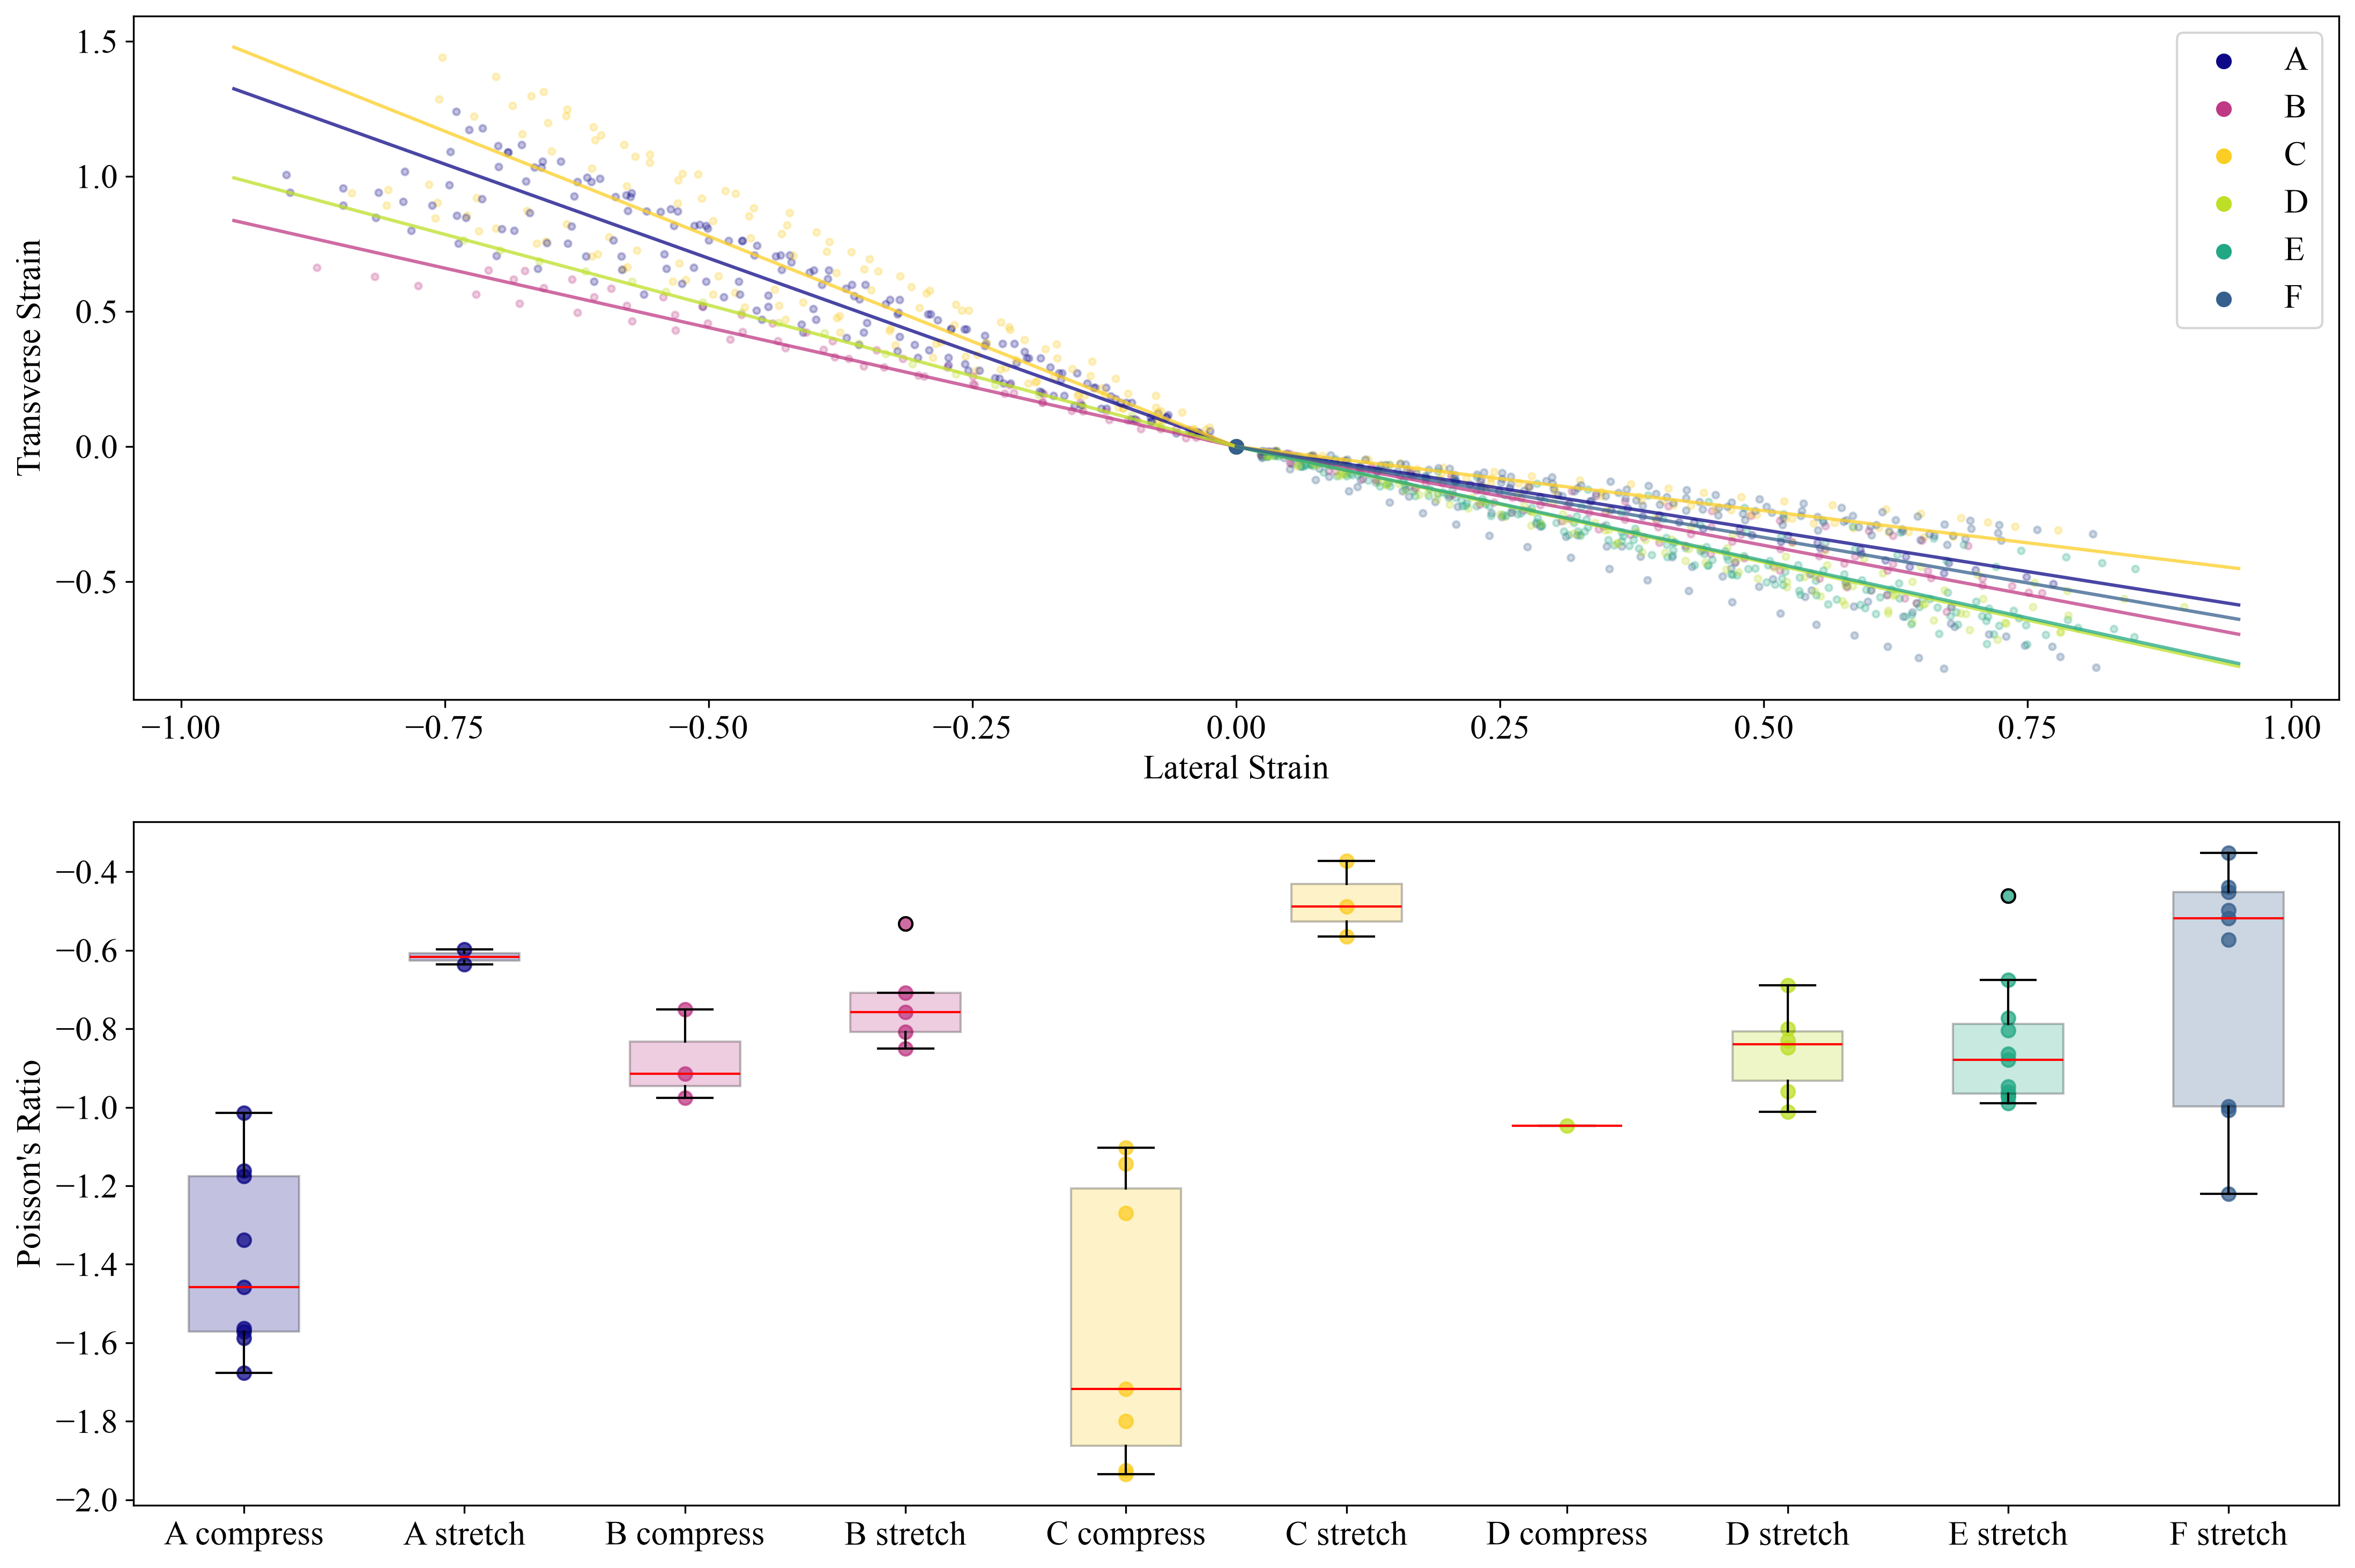

In [7]:
condition_poisson = dict()

fig, axs = plt.subplots(2,1, figsize=(15,10))
for d in dates :
    excel_path = Path(root) / "data" / f"{d}_poisson_ratio.xlsx" # change as needed
    xl_file = pd.ExcelFile(excel_path)

    for gel in xl_file.sheet_names :
        c = gel.split("_")[0]

        gel = pd.read_excel(xl_file, sheet_name=gel)

        # find methods that succeeded with current gel
        used_methods = []
        for col in gel.columns :
            if col[:7] == "poisson" and col[8:] not in used_methods : used_methods.append(col[8:])

        for m in used_methods :
            if m in selected_methods : # consider if the method is one that was selected

                # calculate poisson's ratio
                poisson = pr.calculate_poisson_ratio(gel["lat_length"], gel[f"trans_length {m}"])

                lat = gel["lat_strain"]; trans = gel[f"trans_strain {m}"]

                # determine direction of lateral strain
                lateral_direction = "stretch" if lat.iloc[-1] > 0 else "compress"

                # add poisson's ratio to condition-direction list
                if f"{c} {lateral_direction}" not in condition_poisson : condition_poisson[f"{c} {lateral_direction}"] = [-poisson]
                else : condition_poisson[f"{c} {lateral_direction}"].append(-poisson)

                # plot lateral strain v. transverse strain for gel
                axs[0].scatter(gel["lat_strain"], gel[f"trans_strain {m}"], color=colors[c], marker=".", alpha=0.25)

sorted_condition_poisson = {k:v for k,v in sorted(condition_poisson.items(), key=lambda item: item[0])}

for c, p_lst in sorted_condition_poisson.items() :
    c1 = c.split(" ")[0]; d = c.split(" ")[1]

    # to plot mean, use mean poisson's ratio as slope
    m = np.mean(p_lst)

    if d == "stretch" : x = np.arange(0, 1, 0.05)
    else : x = np.arange(0, -1, -0.05)

    means = [m * n for n in x]
    axs[0].plot(x, means, color=colors[c1],alpha=0.75)

    # plot poisson's ratio for scatter-boxplot
    axs[1].scatter([c] * len(p_lst), p_lst, color=colors[c1], alpha=0.75)

# plot boxplot of each condition-direction's poisson ratio
bp = axs[1].boxplot(
    sorted_condition_poisson.values(),
    tick_labels=sorted_condition_poisson.keys(),
    positions=range(len(sorted_condition_poisson)),
    patch_artist=True
)

for patch, c in zip(bp["boxes"], sorted_condition_poisson) :
    patch.set_facecolor(colors[c.split(" ")[0]])
    patch.set_alpha(0.25)

for median in bp["medians"] :
    median.set(color="red", linewidth=1)
    
for c1, c2 in colors.items() :
    axs[0].scatter(0,0, label=c1, color=c2)

axs[0].set_xlabel("Lateral Strain"); axs[0].set_ylabel("Transverse Strain")
axs[0].legend()

axs[1].set_ylabel("Poisson's Ratio")
plt.tight_layout()
plt.show()